### Магистратура, 2 семестр
### Дисциплина: Высокопроизводительные вычисления
### Лабораторная работа №2 (VectorSum)
### Выполнил: 6133-010402D Журавлев Н.С.

### Проверка GPU и CUDA

In [1]:
!nvidia-smi
!nvcc --version

Mon Apr  6 21:06:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Основной CUDA-код

In [2]:
%%writefile vector_sum.cu
#include <cuda_runtime.h>

#include <algorithm>
#include <chrono>
#include <cstdlib>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <random>
#include <vector>

#define CUDA_CHECK(call)                                                       \
    do {                                                                       \
        cudaError_t err = (call);                                              \
        if (err != cudaSuccess) {                                              \
            std::cerr << "CUDA error: " << cudaGetErrorString(err)             \
                      << " at " << __FILE__ << ":" << __LINE__ << std::endl;   \
            std::exit(EXIT_FAILURE);                                           \
        }                                                                      \
    } while (0)

constexpr int BLOCK_SIZE = 256;
constexpr int REPEATS = 10;

template <typename T>
__global__ void reduce_kernel(const T* input, long long* output, std::size_t n) {
    extern __shared__ long long sdata[];

    unsigned int tid = threadIdx.x;
    std::size_t start = static_cast<std::size_t>(blockIdx.x) * blockDim.x * 2 + tid;

    long long local_sum = 0;

    if (start < n) {
        local_sum += static_cast<long long>(input[start]);
    }
    if (start + blockDim.x < n) {
        local_sum += static_cast<long long>(input[start + blockDim.x]);
    }

    sdata[tid] = local_sum;
    __syncthreads();

    for (unsigned int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (tid < stride) {
            sdata[tid] += sdata[tid + stride];
        }
        __syncthreads();
    }

    if (tid == 0) {
        output[blockIdx.x] = sdata[0];
    }
}

struct GpuBuffers {
    int* d_input = nullptr;
    long long* d_partial1 = nullptr;
    long long* d_partial2 = nullptr;
    std::size_t n = 0;
    std::size_t max_partials = 0;
};

void allocate_buffers(GpuBuffers& buf, std::size_t n) {
    buf.n = n;
    buf.max_partials = (n + BLOCK_SIZE * 2 - 1) / (BLOCK_SIZE * 2);
    if (buf.max_partials == 0) {
        buf.max_partials = 1;
    }

    CUDA_CHECK(cudaMalloc(&buf.d_input, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&buf.d_partial1, buf.max_partials * sizeof(long long)));
    CUDA_CHECK(cudaMalloc(&buf.d_partial2, buf.max_partials * sizeof(long long)));
}

void free_buffers(GpuBuffers& buf) {
    if (buf.d_input) CUDA_CHECK(cudaFree(buf.d_input));
    if (buf.d_partial1) CUDA_CHECK(cudaFree(buf.d_partial1));
    if (buf.d_partial2) CUDA_CHECK(cudaFree(buf.d_partial2));

    buf.d_input = nullptr;
    buf.d_partial1 = nullptr;
    buf.d_partial2 = nullptr;
    buf.n = 0;
    buf.max_partials = 0;
}

std::vector<int> generate_vector(std::size_t n) {
    std::mt19937 rng(static_cast<unsigned int>(12345 + n));
    std::uniform_int_distribution<int> dist(1, 10);

    std::vector<int> data(n);
    for (auto& x : data) {
        x = dist(rng);
    }
    return data;
}

long long cpu_sum(const std::vector<int>& data) {
    long long sum = 0;
    for (int x : data) {
        sum += x;
    }
    return sum;
}

// Запуск редукции на уже лежащих в GPU данных.
// Если kernel_time_ms != nullptr, то измеряется только время ядер через CUDA events.
long long reduce_on_device(
    const int* d_input,
    long long* d_partial1,
    long long* d_partial2,
    std::size_t n,
    float* kernel_time_ms = nullptr
) {
    cudaEvent_t start_event, stop_event;
    bool measure_kernel = (kernel_time_ms != nullptr);

    if (measure_kernel) {
        CUDA_CHECK(cudaEventCreate(&start_event));
        CUDA_CHECK(cudaEventCreate(&stop_event));
        CUDA_CHECK(cudaEventRecord(start_event));
    }

    std::size_t current_n = n;
    std::size_t grid_size = (current_n + BLOCK_SIZE * 2 - 1) / (BLOCK_SIZE * 2);

    reduce_kernel<int><<<grid_size, BLOCK_SIZE, BLOCK_SIZE * sizeof(long long)>>>(
        d_input, d_partial1, current_n
    );
    CUDA_CHECK(cudaGetLastError());

    current_n = grid_size;

    long long* in = d_partial1;
    long long* out = d_partial2;

    while (current_n > 1) {
        grid_size = (current_n + BLOCK_SIZE * 2 - 1) / (BLOCK_SIZE * 2);

        reduce_kernel<long long><<<grid_size, BLOCK_SIZE, BLOCK_SIZE * sizeof(long long)>>>(
            in, out, current_n
        );
        CUDA_CHECK(cudaGetLastError());

        current_n = grid_size;
        std::swap(in, out);
    }

    if (measure_kernel) {
        CUDA_CHECK(cudaEventRecord(stop_event));
        CUDA_CHECK(cudaEventSynchronize(stop_event));
        CUDA_CHECK(cudaEventElapsedTime(kernel_time_ms, start_event, stop_event));
        CUDA_CHECK(cudaEventDestroy(start_event));
        CUDA_CHECK(cudaEventDestroy(stop_event));
    } else {
        CUDA_CHECK(cudaDeviceSynchronize());
    }

    long long result = 0;
    CUDA_CHECK(cudaMemcpy(&result, in, sizeof(long long), cudaMemcpyDeviceToHost));
    return result;
}

// Полное время GPU: H2D + kernels + D2H
long long gpu_sum_full(const std::vector<int>& data, GpuBuffers& buf, double& elapsed_ms) {
    auto start = std::chrono::high_resolution_clock::now();

    CUDA_CHECK(cudaMemcpy(
        buf.d_input,
        data.data(),
        data.size() * sizeof(int),
        cudaMemcpyHostToDevice
    ));

    long long result = reduce_on_device(
        buf.d_input, buf.d_partial1, buf.d_partial2, data.size(), nullptr
    );

    auto stop = std::chrono::high_resolution_clock::now();
    elapsed_ms = std::chrono::duration<double, std::milli>(stop - start).count();

    return result;
}

// Только время CUDA-ядер: данные заранее уже на GPU
long long gpu_sum_kernel_only(const std::vector<int>& data, GpuBuffers& buf, double& elapsed_ms) {
    CUDA_CHECK(cudaMemcpy(
        buf.d_input,
        data.data(),
        data.size() * sizeof(int),
        cudaMemcpyHostToDevice
    ));

    float kernel_ms = 0.0f;
    long long result = reduce_on_device(
        buf.d_input, buf.d_partial1, buf.d_partial2, data.size(), &kernel_ms
    );

    elapsed_ms = static_cast<double>(kernel_ms);
    return result;
}

void warm_up_gpu() {
    CUDA_CHECK(cudaFree(0));

    std::vector<int> warm_data(1024, 1);
    GpuBuffers warm_buf;
    allocate_buffers(warm_buf, warm_data.size());

    double full_ms = 0.0;
    volatile long long warm_result = gpu_sum_full(warm_data, warm_buf, full_ms);
    (void)warm_result;

    free_buffers(warm_buf);
}

int main() {
    cudaDeviceProp prop;
    CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));

    std::cout << "GPU device: " << prop.name << "\n";
    std::cout << "BLOCK_SIZE = " << BLOCK_SIZE << "\n";
    std::cout << "REPEATS    = " << REPEATS << "\n\n";

    warm_up_gpu();
    std::cout << "GPU warm-up completed.\n\n";

    std::vector<std::size_t> sizes = {
        1000, 2500, 5000, 7500, 10000,
        50000, 70000, 100000, 250000, 500000, 700000, 1000000
    };

    std::ofstream csv("results.csv");
    csv << "N,CPU_sum,GPU_sum_full,GPU_sum_kernel,CPU_Time_ms,GPU_Full_Time_ms,GPU_Kernel_Time_ms,Speedup_Full,Speedup_Kernel,Absolute_Error_Full,Absolute_Error_Kernel\n";

    std::cout << std::left
              << std::setw(12) << "N"
              << std::setw(16) << "CPU_sum"
              << std::setw(16) << "GPU_full_sum"
              << std::setw(16) << "GPU_kern_sum"
              << std::setw(12) << "CPU_ms"
              << std::setw(14) << "GPU_full_ms"
              << std::setw(14) << "GPU_kern_ms"
              << std::setw(14) << "Sp_full"
              << std::setw(14) << "Sp_kernel"
              << std::setw(12) << "Err_full"
              << std::setw(12) << "Err_kernel"
              << "\n";

    std::cout << std::string(152, '-') << "\n";

    for (std::size_t n : sizes) {
        std::vector<int> data = generate_vector(n);

        GpuBuffers buf;
        allocate_buffers(buf, n);

        long long cpu_result = 0;
        long long gpu_full_result = 0;
        long long gpu_kernel_result = 0;

        double cpu_total_ms = 0.0;
        double gpu_full_total_ms = 0.0;
        double gpu_kernel_total_ms = 0.0;

        for (int r = 0; r < REPEATS; ++r) {
            auto cpu_start = std::chrono::high_resolution_clock::now();
            cpu_result = cpu_sum(data);
            auto cpu_stop = std::chrono::high_resolution_clock::now();

            double cpu_ms = std::chrono::duration<double, std::milli>(cpu_stop - cpu_start).count();
            cpu_total_ms += cpu_ms;
        }

        for (int r = 0; r < REPEATS; ++r) {
            double gpu_full_ms = 0.0;
            gpu_full_result = gpu_sum_full(data, buf, gpu_full_ms);
            gpu_full_total_ms += gpu_full_ms;
        }

        for (int r = 0; r < REPEATS; ++r) {
            double gpu_kernel_ms = 0.0;
            gpu_kernel_result = gpu_sum_kernel_only(data, buf, gpu_kernel_ms);
            gpu_kernel_total_ms += gpu_kernel_ms;
        }

        free_buffers(buf);

        double cpu_avg_ms = cpu_total_ms / REPEATS;
        double gpu_full_avg_ms = gpu_full_total_ms / REPEATS;
        double gpu_kernel_avg_ms = gpu_kernel_total_ms / REPEATS;

        double speedup_full = (gpu_full_avg_ms > 0.0) ? (cpu_avg_ms / gpu_full_avg_ms) : 0.0;
        double speedup_kernel = (gpu_kernel_avg_ms > 0.0) ? (cpu_avg_ms / gpu_kernel_avg_ms) : 0.0;

        long long err_full = std::llabs(cpu_result - gpu_full_result);
        long long err_kernel = std::llabs(cpu_result - gpu_kernel_result);

        std::cout << std::fixed << std::setprecision(4)
                  << std::left
                  << std::setw(12) << n
                  << std::setw(16) << cpu_result
                  << std::setw(16) << gpu_full_result
                  << std::setw(16) << gpu_kernel_result
                  << std::setw(12) << cpu_avg_ms
                  << std::setw(14) << gpu_full_avg_ms
                  << std::setw(14) << gpu_kernel_avg_ms
                  << std::setw(14) << speedup_full
                  << std::setw(14) << speedup_kernel
                  << std::setw(12) << err_full
                  << std::setw(12) << err_kernel
                  << "\n";

        csv << n << ","
            << cpu_result << ","
            << gpu_full_result << ","
            << gpu_kernel_result << ","
            << cpu_avg_ms << ","
            << gpu_full_avg_ms << ","
            << gpu_kernel_avg_ms << ","
            << speedup_full << ","
            << speedup_kernel << ","
            << err_full << ","
            << err_kernel << "\n";
    }

    csv.close();

    std::cout << "\nResults saved to results.csv\n";
    return 0;
}

Writing vector_sum.cu


### Компиляция

In [3]:
!nvcc -O3 -std=c++17 vector_sum.cu -o vector_sum

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


### Запуск экспериментов

In [4]:
!./vector_sum

GPU device: Tesla T4
BLOCK_SIZE = 256
REPEATS    = 10

GPU warm-up completed.

N           CPU_sum         GPU_full_sum    GPU_kern_sum    CPU_ms      GPU_full_ms   GPU_kern_ms   Sp_full       Sp_kernel     Err_full    Err_kernel  
--------------------------------------------------------------------------------------------------------------------------------------------------------
1000        5558            5558            5558            0.0002      0.0312        0.0130        0.0076        0.0183        0           0           
2500        13616           13616           13616           0.0005      0.0310        0.0124        0.0169        0.0422        0           0           
5000        27519           27519           27519           0.0011      0.0354        0.0141        0.0308        0.0772        0           0           
7500        41117           41117           41117           0.0016      0.0386        0.0123        0.0419        0.1312        0           0           
100

### Таблица и графики

,N,CPU_Time_ms,GPU_Full_Time_ms,GPU_Kernel_Time_ms,Speedup_Full,Speedup_Kernel,Absolute_Error_Full,Absolute_Error_Kernel
0,1000,0.0002,0.0312,0.0130,0.0076,0.0183,0,0
1,2500,0.0005,0.0310,0.0124,0.0169,0.0422,0,0
2,5000,0.0011,0.0354,0.0141,0.0308,0.0772,0,0
3,7500,0.0016,0.0386,0.0123,0.0419,0.1312,0,0
4,10000,0.0021,0.0442,0.0125,0.0486,0.1715,0,0
5,50000,0.0115,0.0887,0.0162,0.1302,0.7122,0,0
6,70000,0.0154,0.1112,0.0191,0.1388,0.8073,0,0
7,100000,0.0211,0.1439,0.0206,0.1467,1.0263,0,0
8,250000,0.0507,0.3182,0.0301,0.1592,1.6860,0,0
9,500000,0.1104,0.5137,0.0454,0.2150,2.4333,0,0


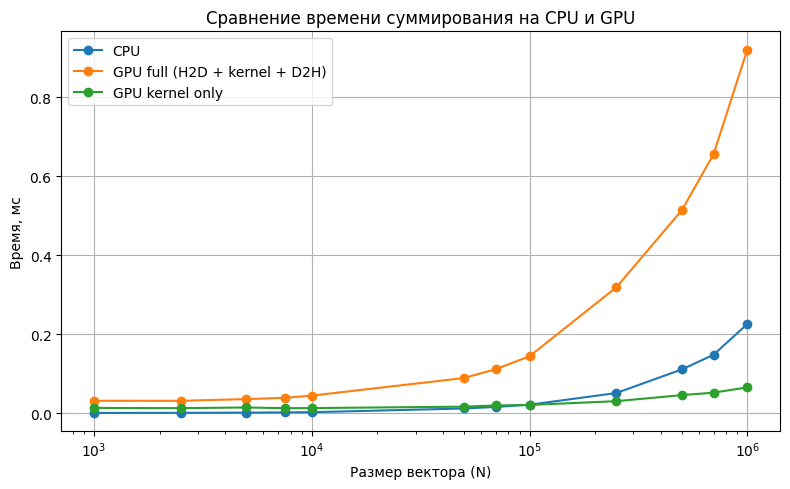

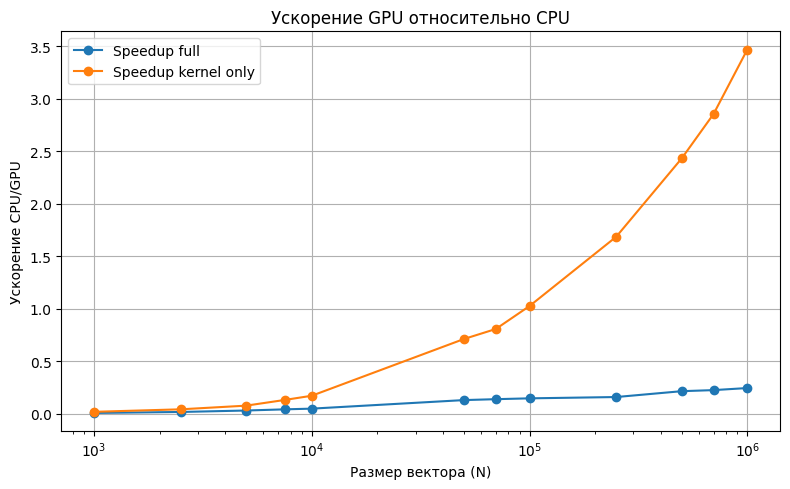

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

display(
    df[[
        "N",
        "CPU_Time_ms",
        "GPU_Full_Time_ms",
        "GPU_Kernel_Time_ms",
        "Speedup_Full",
        "Speedup_Kernel",
        "Absolute_Error_Full",
        "Absolute_Error_Kernel"
    ]].round(4)
)

plt.figure(figsize=(8, 5))
plt.plot(df["N"], df["CPU_Time_ms"], marker="o", label="CPU")
plt.plot(df["N"], df["GPU_Full_Time_ms"], marker="o", label="GPU full (H2D + kernel + D2H)")
plt.plot(df["N"], df["GPU_Kernel_Time_ms"], marker="o", label="GPU kernel only")
plt.xscale("log")
plt.xlabel("Размер вектора (N)")
plt.ylabel("Время, мс")
plt.title("Сравнение времени суммирования на CPU и GPU")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("times_compare.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df["N"], df["Speedup_Full"], marker="o", label="Speedup full")
plt.plot(df["N"], df["Speedup_Kernel"], marker="o", label="Speedup kernel only")
plt.xscale("log")
plt.xlabel("Размер вектора (N)")
plt.ylabel("Ускорение CPU/GPU")
plt.title("Ускорение GPU относительно CPU")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("speedup_compare.png", dpi=200)
plt.show()